In [1]:
from IPython.display import clear_output, Image, display
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

current_time = 0

def processImg(img):
    global current_time
    if current_time == 0:
        current_time = time.time()
    else:
        last_time = current_time
        current_time = time.time()
        delta = current_time - last_time
        fps_show = 1.0 / delta if delta > 0 else 0
        cv2.putText(img, f"FPS: {int(fps_show)}", (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    return img

def arrayShow(img):
    _, ret = cv2.imencode('.jpg', img)
    return Image(data=ret)

In [2]:
OPENCV_OBJECT_TRACKERS = {
    "csrt": cv2.legacy.TrackerCSRT_create,
    "kcf": cv2.legacy.TrackerKCF_create,
    "boosting": cv2.legacy.TrackerBoosting_create,
    "mil": cv2.legacy.TrackerMIL_create,
    "medianflow": cv2.legacy.TrackerMedianFlow_create,
    "mosse": cv2.legacy.TrackerMOSSE_create
}

video_path = "soccer_06.mp4"
field = cv2.imread("hot.jpg")
PIXEL_TO_M = 0.02

In [3]:
def multi_tracking(video_path, method="csrt"):
    trackers = cv2.legacy.MultiTracker_create()
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    ret, frame = cap.read()
    if not ret:
        print("Video read failed")
        return None

    h, w = frame.shape[:2]
    new_w = w
    new_h = h
    mid_line = new_w // 2

    init_boxes = []
    while True:
        box = cv2.selectROI("Select Player", frame, False, True)
        init_boxes.append(box)
        if cv2.waitKey(0) & 0xFF == ord("q"):
            break
    cv2.destroyAllWindows()

    for box in init_boxes:
        tracker = OPENCV_OBJECT_TRACKERS[method]()
        trackers.add(tracker, frame, box)

    trajectories = {}
    speeds = {}
    cross_frame = {}
    cross_flag = {}
    start_side = {}
    # 存每个球员当前实时速度
    curr_speed_m = {}

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 画中间红色中线
        cv2.line(frame, (mid_line, 0), (mid_line, new_h), (0,0,255), 2)

        success, boxes = trackers.update(frame)
        centers = []

        for i, box in enumerate(boxes):
            x, y, wb, hb = [int(v) for v in box]
            cx = x + wb//2
            cy = y + hb//2
            centers.append((cx, cy))

            if i not in trajectories:
                trajectories[i] = []
                cross_flag[i] = False
                start_side[i] = 0 if cx < mid_line else 1
                curr_speed_m[i] = 0.0
            trajectories[i].append((cx, cy, frame_idx))

            # 画框 + 中心点
            cv2.rectangle(frame, (x,y),(x+wb,y+hb),(0,255,0),2)
            cv2.circle(frame,(cx,cy),3,(0,0,255),-1)

            # 显示 Player编号 + 实时速度
            text1 = f"Player {i+1}"
            text2 = f"Speed: {curr_speed_m[i]:.2f} m/s"
            cv2.putText(frame, text1, (x, y-30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
            cv2.putText(frame, text2, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

        # 计算实时速度
        if frame_idx > 0:
            for i, traj in trajectories.items():
                if len(traj) >= 2:
                    x1,y1,f1 = traj[-2]
                    x2,y2,f2 = traj[-1]
                    dist = ((x2-x1)**2 + (y2-y1)**2)**0.5
                    t = max((f2-f1)/fps, 1e-6)
                    mspd = (dist * PIXEL_TO_M) / t
                    curr_speed_m[i] = mspd

                    if i not in speeds:
                        speeds[i] = []
                    speeds[i].append(mspd)

        # 过中线判断：换侧才记录第一次
        for i, (cx, cy) in enumerate(centers):
            if not cross_flag[i]:
                now_side = 0 if cx < mid_line else 1
                if now_side != start_side[i]:
                    cross_flag[i] = True
                    cross_frame[i] = frame_idx

        frame = processImg(frame)
        clear_output(wait=True)
        display(arrayShow(frame))
        frame_idx += 1
        time.sleep(0.025)

    cap.release()

    # 输出格式
    print("\n===== Speed & Cross Line =====")
    for i in sorted(trajectories.keys()):
        if i in speeds:
            m_list = speeds[i]
            print(f"\nPlayer {i+1}")
            print(f"平均速度: {np.mean(m_list):.2f} m/s")
            print(f"最大速度: {np.max(m_list):.2f} m/s")
            if i in cross_frame:
                sec = cross_frame[i] / fps
                print(f"过中线在第{sec:.2f}秒")
            print("-" * 50)

    return trajectories

In [4]:
def show_individual_heatmaps(trajectories, bg_img):
    h, w = bg_img.shape[:2]
    for pid, traj in trajectories.items():
        hm = np.zeros((h, w), dtype=np.float32)
        for i in range(1, len(traj)):
            x1,y1,_ = traj[i-1]
            x2,y2,_ = traj[i]
            cv2.line(hm, (x1,y1), (x2,y2), 1, 2)
        hm = cv2.GaussianBlur(hm, (51,51), 0)
        hm = cv2.normalize(hm, None, 0,255,cv2.NORM_MINMAX).astype(np.uint8)
        hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
        bg = cv2.resize(bg_img, (w,h))
        out = cv2.addWeighted(bg, 0.6, hm, 0.4, 0)
        plt.figure(figsize=(10,5))
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        plt.title(f"Player {pid+1} Heatmap")
        plt.axis("off")
        plt.show()

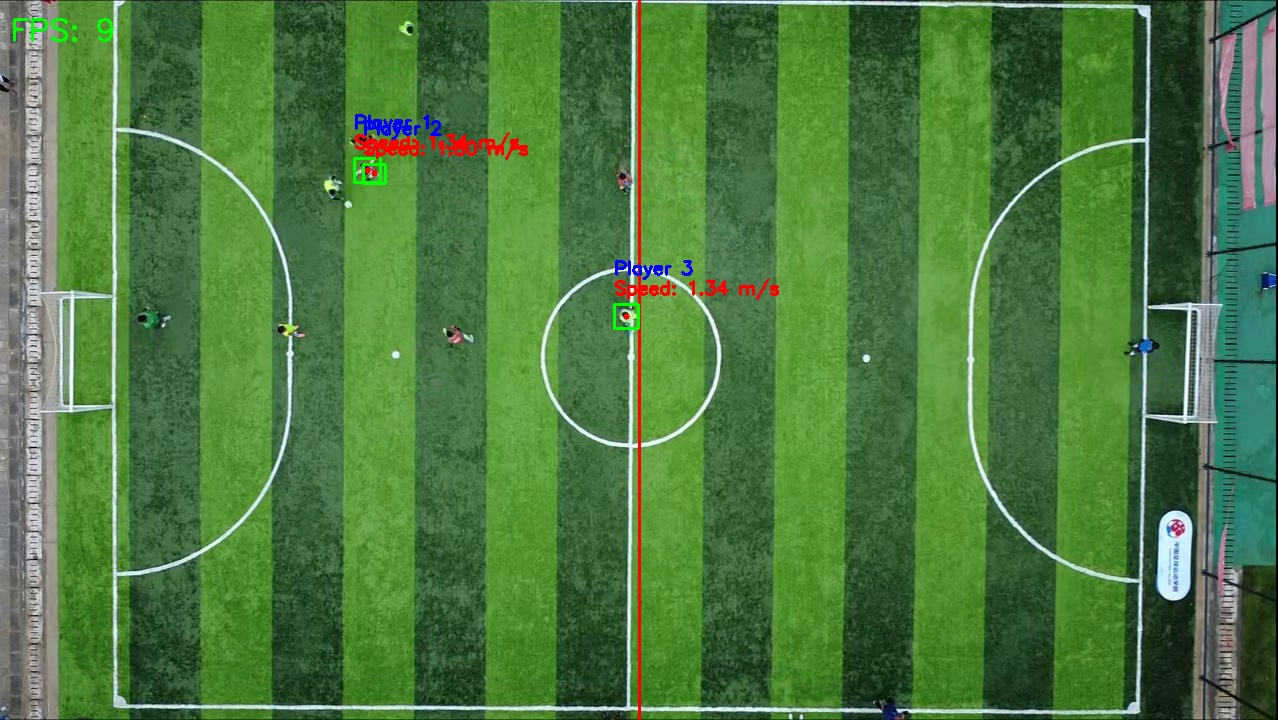


===== Speed & Cross Line =====

Player 1
平均速度: 1.56 m/s
最大速度: 8.42 m/s
过中线在第1.67秒
--------------------------------------------------

Player 2
平均速度: 1.80 m/s
最大速度: 7.25 m/s
过中线在第5.63秒
--------------------------------------------------

Player 3
平均速度: 1.29 m/s
最大速度: 7.00 m/s
过中线在第1.37秒
--------------------------------------------------


In [5]:
method = input("Algorithm (csrt/kcf/mosse/mil): ").lower()
if method in OPENCV_OBJECT_TRACKERS:
    traj = multi_tracking(video_path, method)
else:
    print("Wrong algorithm")

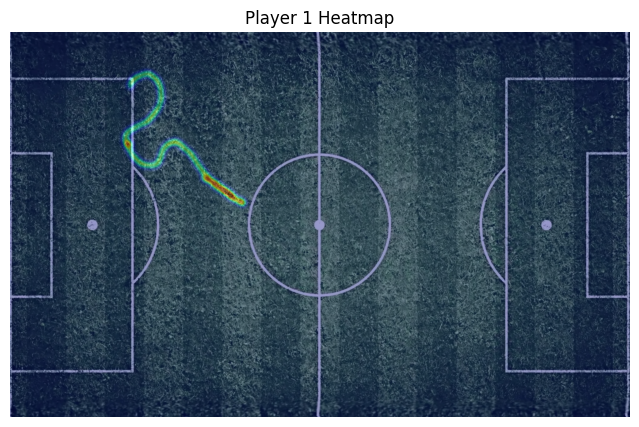

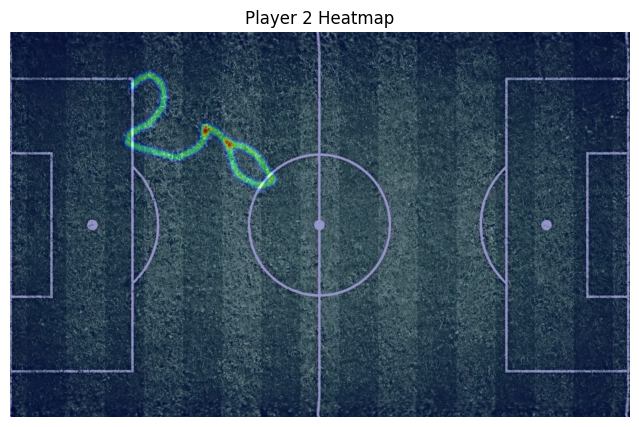

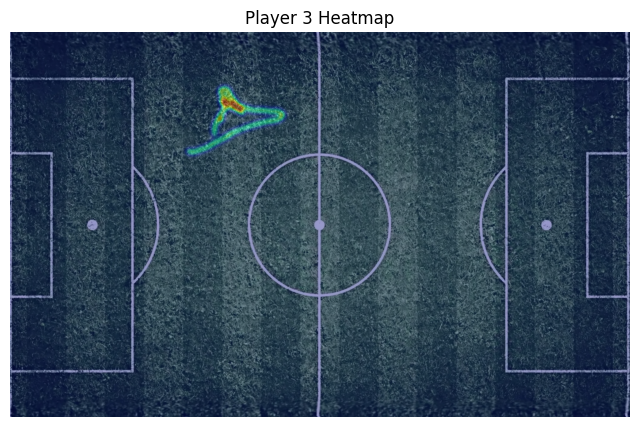

In [6]:
show_individual_heatmaps(traj, field)